In [7]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end_vmapped, 
    square_input_wave,
    MagneticPhaseSample,
    KrivanekLens, 
    DistortedLens, 
    Biprism,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_jax_scan, evaluate_gaussians_for
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.utils import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.plotting import plot_model, PlotParams

In [8]:
def run_model(input_window_width_m=1e-6,
              aperture_scale_factor=1.0,
              num_pixels=512,
              voltage_eV=200e3,
              input_object_xy=(0.0, 0.0),
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-80,
              projector_focal_length=5e-3,  # 5 mm
              projector_magnification=-50,
              defocus=0.0,
              biprism_deflection=0.0005,
              C12_aberration=0.0,
              C21_aberration=0.0,
              isotropic_distortion=0.0,
              anisotropic_distortion=0.0,
              num_rays=50_000,
              beam_waist=1e-8,
              plot_input_field=False,
              plot_output_rays=False,
              plot_ray_diagram=False):

    # Create input field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels
    total_mag = obj_magnification * projector_magnification

    input_grid = Detector(
    z=defocus,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    rays_in = square_input_wave(voltage=voltage_eV,
                                aperture_length=input_window_width_m * aperture_scale_factor,
                                num_rays=num_rays,
                                waist=beam_waist,
                                z0=defocus,
                                centre_xy=input_object_xy)
    
    # Make square magnetic sample
    sample = MagneticPhaseSample(
        z=input_grid.z,
        strength=0e-12, # Optical path length shift in metres - adjust to change magnitude
        width=0.1e-6,
        height=0.1e-6,
        x0=0.1e-6 + input_object_xy[0],
        y0=0.05e-6 + input_object_xy[1],
        theta=-0.15,
        modulation_strength=0.002,
        skew_strength=0.01,
        radial_strength=0.5,
        edge_sharpness=1e8,
    )

    rays_after_sample = run_to_end_vmapped(rays_in, (sample,))

    if plot_input_field:
        input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_after_sample, input_grid).block_until_ready()

        fig, axs = plt.subplots(1, 2)
        axs[0].imshow(np.abs(input_field), extent=input_grid.extent, origin='lower', cmap='inferno')
        axs[0].set_title('Input Field Amplitude')
        axs[1].imshow(np.angle(input_field), extent=input_grid.extent, origin='lower', cmap='twilight')
        axs[1].set_title('Input Field Phase')
        plt.tight_layout()

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    # z3 = object plane distance from projector lens to it's image plane - again it's negative since the image plane is before the lens
    # z4 = distance fromt projector lens to detector
    z3, z4 = calculate_z1_and_z2_from_M_and_f(
        M=projector_magnification,
        f=projector_focal_length,
    )
    z1, z2, z3, z4 = map(abs, (z1, z2, z3, z4))  # Ensure distances are positive

    aberration_coefficients = KrivanekCoeffs(
        C12=C12_aberration,
        C21=C21_aberration,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=z1 + z2/2, strength=biprism_deflection, width=1e-11)
    projector_lens = DistortedLens(z=z1+z2+z3, object_plane_dist=z3, focal_length=projector_focal_length,
                                    IsoDist=isotropic_distortion, AnisoDist=anisotropic_distortion)
    detector = Detector(
        z=z1 + z2,
        pixel_size=(pixel_size * abs(obj_magnification), pixel_size * abs(obj_magnification)),
        shape=(num_pixels, num_pixels),
    )
    extent = detector.extent

    rays_out = run_to_end_vmapped(rays_in, (sample, objective_lens, biprism, detector))
    output_field = evaluate_gaussians_gpu_kernel_wrapper(rays_out, detector).block_until_ready()

    fig, axs = plt.subplots()
    axs.imshow(np.abs(output_field) ** 2, extent=extent, cmap='gray')
    axs.set_title('Hologram Intensity')
    plt.tight_layout()

    if plot_output_rays:
        axs.plot(rays_out.x, rays_out.y, 'r.', markersize=0.5, alpha=0.1)


    if plot_ray_diagram:
        plot_model(
            components=[sample, objective_lens, biprism, detector],
            rays=rays_in[::10000],
            plot_params=PlotParams(
                figsize=(10, 6),
            ),
        )

    return output_field, extent

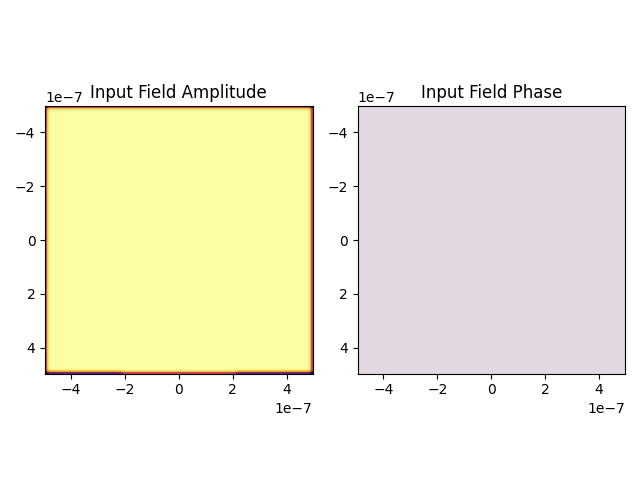

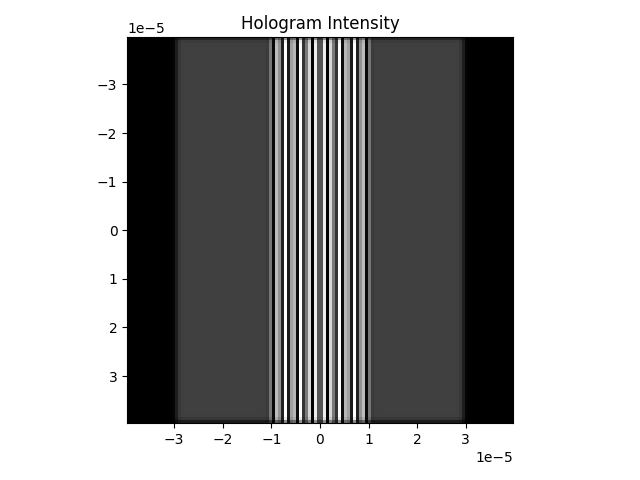

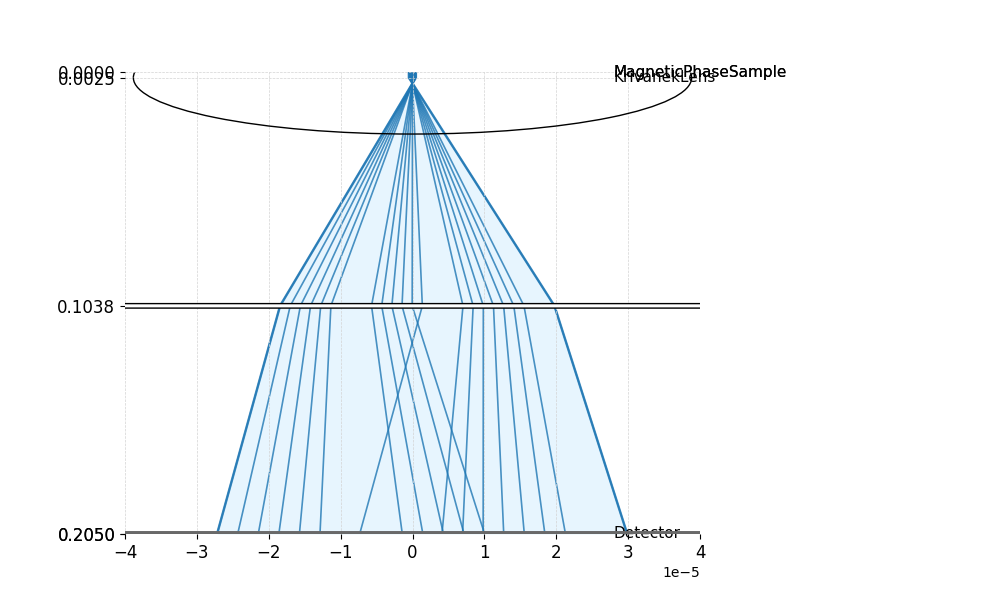

In [9]:
output_field, extent = run_model(
    input_window_width_m=1e-6,
    aperture_scale_factor=1.0,
    num_pixels=128,
    num_rays=200_000,
    beam_waist=1e-8,
    input_object_xy=(0e-7, 0e-7),
    biprism_deflection=1e-4,
    C12_aberration=0,  # Astigmatism
    C21_aberration=0,  # Coma
    isotropic_distortion=1e7,
    anisotropic_distortion=1e7,
    plot_input_field=True,
    plot_output_rays=False,
    plot_ray_diagram=True,
)